### Dataset Import

In [5]:
import kagglehub
import shutil
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment", output_dir="../data")

print("Path to dataset files:", path)

shutil.rmtree("../data/.complete")

100%|██████████| 84.1k/84.1k [00:00<00:00, 1.04MB/s]

Extracting files...
Path to dataset files: ../data


### Exploratory Data Analysis

In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [19]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")

In [20]:
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 390.8 KB


In [22]:
data.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


distribution of the target column

In [23]:
target_col = data.columns[-1]

distribution = (
    data[target_col]
    .value_counts(dropna=False)
    .rename_axis(target_col)
    .reset_index(name="count")
)

distribution["percentage"] = (distribution["count"] / len(data) * 100).round(2)
distribution

,Air Quality,count,percentage
0,Good,2000,40.0
1,Moderate,1500,30.0
2,Poor,1000,20.0
3,Hazardous,500,10.0


duplicated rows

In [24]:
data[data.duplicated()]

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality


missing values

In [25]:
data.isna().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

missing cells

In [26]:
data.isna().sum().sum()

np.int64(0)

TARGET COLUMN ENCODING

In order to only work with numerical data, we will encode the target column to a value between 0 and 3

In [27]:
quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)


data[target_col] = data[target_col].astype("int8")
data[[target_col]].head()

,Air Quality
0,2
1,2
2,2
3,3
4,3


In [28]:
data.head()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,3
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,3


## Feature Distributions by Class

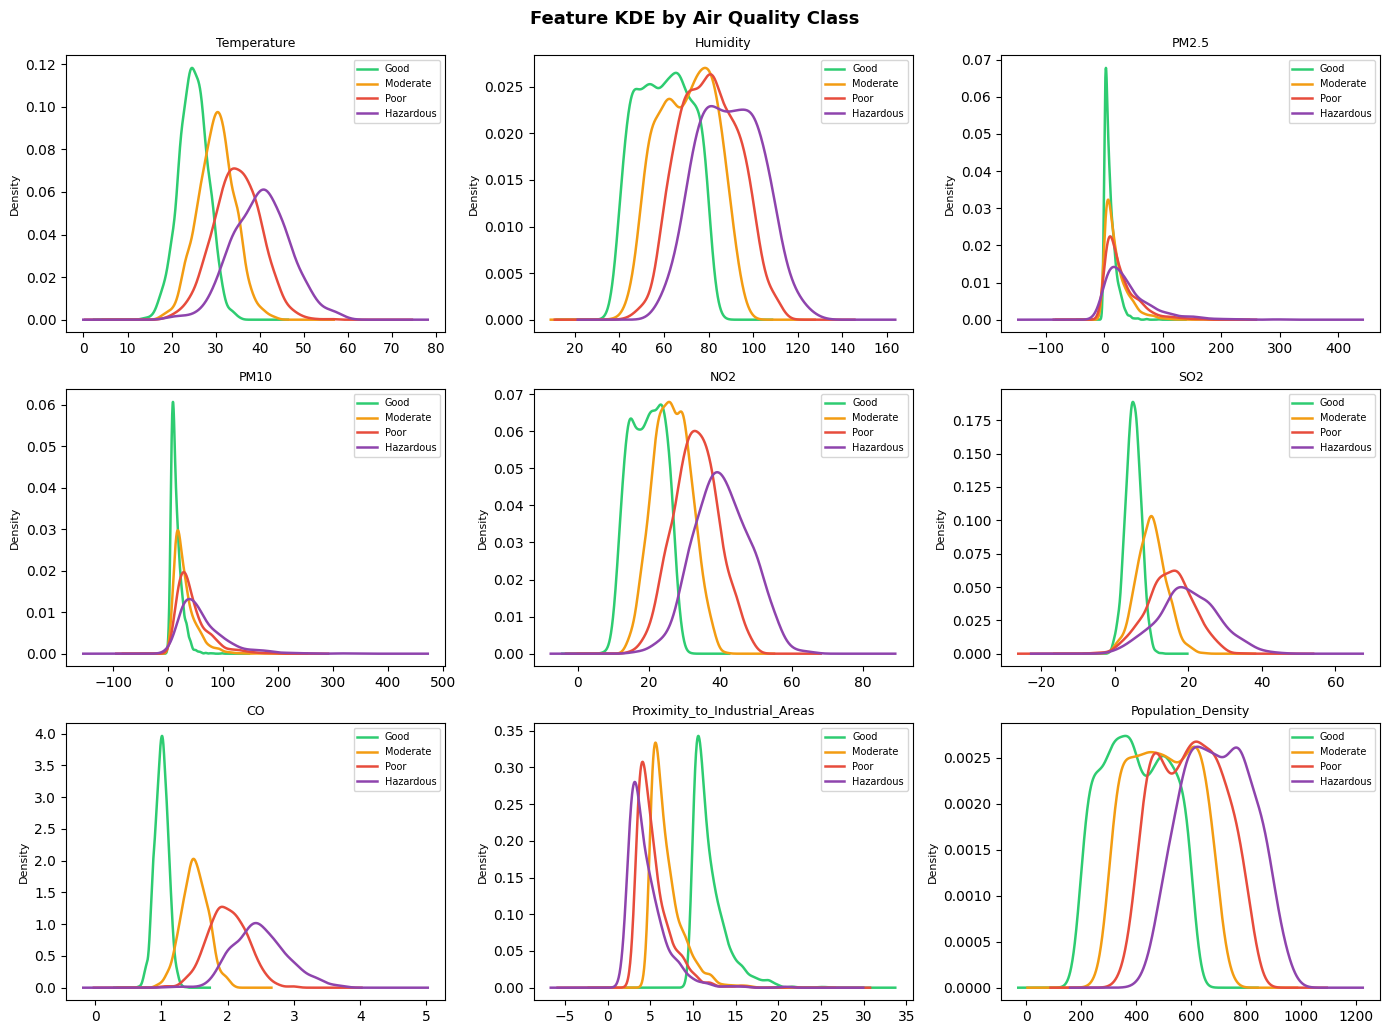

In [ ]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
data[target_col] = data[target_col].map(quality_map).astype("int8")

PALETTE   = {3: "#2ecc71", 2: "#f39c12", 1: "#e74c3c", 0: "#8e44ad"}
LABEL_MAP = {3: "Good",    2: "Moderate", 1: "Poor",   0: "Hazardous"}

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols]
y = data[target_col]

ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))

plot_data = X.copy()
plot_data["label"] = y.map(LABEL_MAP)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label_val, label_name in LABEL_MAP.items():
        subset = plot_data.loc[plot_data["label"] == label_name, col].dropna()
        subset.plot.kde(ax=ax, label=label_name, color=PALETTE[label_val], linewidth=1.8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature KDE by Air Quality Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

As we can see, the KDE plots shows the distribution of each feature by air quality class. Some features like `Temperature` or `CO` show a clear class separation, while others such as `PM2.5` or `Population_Density` show clear overlapping across all classes. A clear pattern can be seen, `Good` and `Hazardous` occupy opposite ends of the distribution in most features, meaning they are relatively easy to distinguish. However, the boundaries between `Moderate` and `Poor` overlap significantly across almost every feature, which will likely be a challenge for classification tasks.

<Axes: >

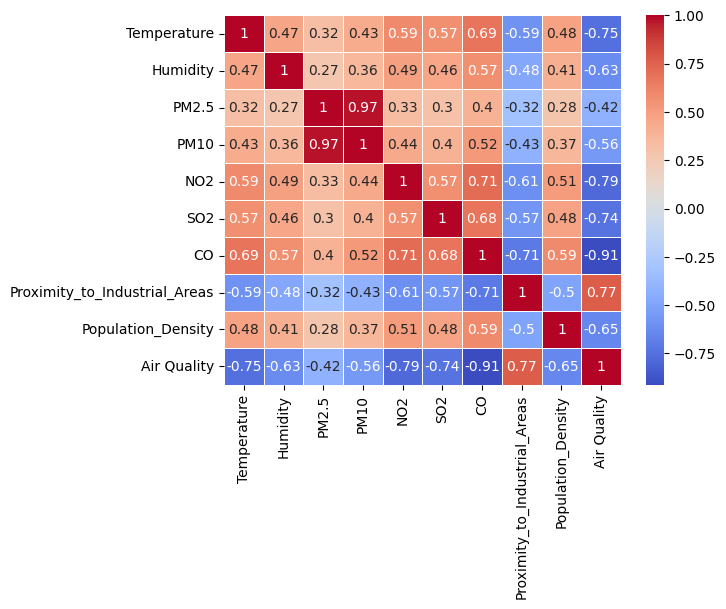

In [30]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

## FEATURE EXTRACTION
We scale numerical features and apply principal component analysis (PCA) retaining 95% of explained variance.

In [31]:
feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols]
y = data[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)
print("Components kept:", pca.n_components_)
print("Explained variance (%):", round(pca.explained_variance_ratio_.sum() * 100, 2))

Original shape: (5000, 9)
Reduced shape: (5000, 7)
Components kept: 7
Explained variance (%): 97.37


In [32]:
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)
pca_df[target_col] = y.reset_index(drop=True)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Air Quality
0,-0.859045,-0.404765,-0.178931,-1.169645,-0.167901,-0.178141,-0.924942,2
1,0.336813,-1.236961,-0.046531,0.579485,-0.298973,-0.621238,-0.066865,2
2,0.545779,0.035014,-0.049391,0.763475,0.443733,-1.137195,-0.731387,2
3,-2.326901,-0.056318,-1.572087,0.488577,0.137286,0.466309,-0.550655,3
4,-2.046358,0.111473,0.843251,-0.368897,0.063047,0.284532,0.457633,3


## PCA VISUALIZATION
Plots to inspect explained variance and class separation in PCA space.

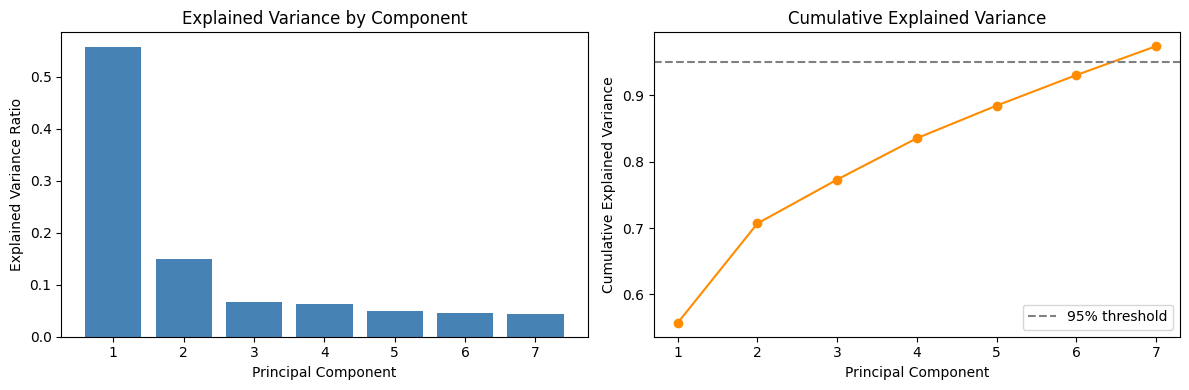

In [33]:
import matplotlib.pyplot as plt
import numpy as np

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
components = np.arange(1, len(explained) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(components, explained, color="steelblue")
ax[0].set_title("Explained Variance by Component")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance Ratio")
ax[0].set_xticks(components)

ax[1].plot(components, cumulative, marker="o", color="darkorange")
ax[1].axhline(0.95, linestyle="--", color="gray", label="95% threshold")
ax[1].set_title("Cumulative Explained Variance")
ax[1].set_xlabel("Principal Component")
ax[1].set_ylabel("Cumulative Explained Variance")
ax[1].set_xticks(components)
ax[1].legend()

plt.tight_layout()
plt.show()

This plots show us that some components explain most of the variance, but all of them are needed for full understanding.

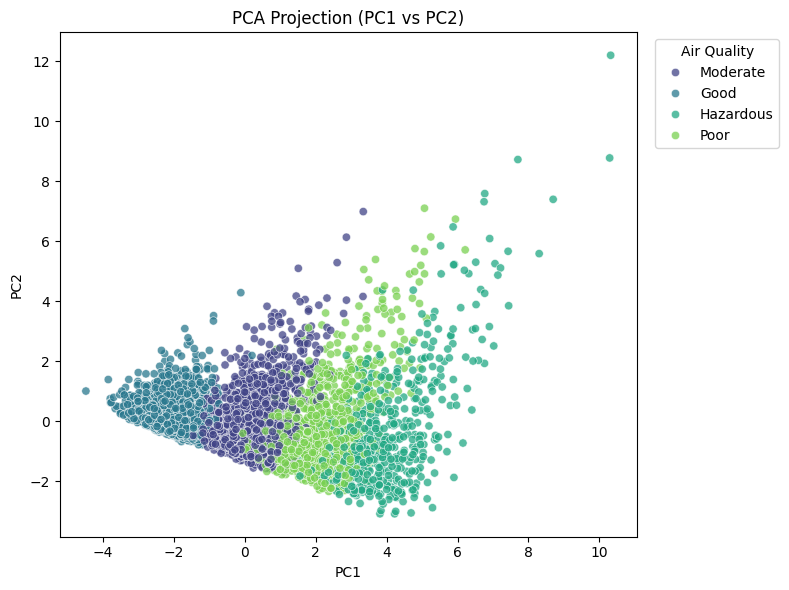

In [34]:
plot_df = pca_df.copy()
# we use the original target values for better visualization
label_map = {3: "Good", 2: "Moderate", 1: "Poor", 0: "Hazardous"}
plot_df["label"] = plot_df[target_col].map(label_map).fillna(plot_df[target_col].astype(str))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="label",
    palette="viridis",
    alpha=0.75
)
plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Air Quality", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Even if PC1 and PC2 explain most of the variance (0.75), they dont explain all of it, but it is useful. The PC1 vs PC2 scatter shows partial class structure, but classes still overlap notably in 2D. Even if this occurs in 2D, it is not mandatory to happen when we add mor edimensions (3D, 4D...), therefore, in a recall critical problem, as air quality is, given this overlapping, we can expect a high amount of false positives and negatives (being the negatives critical) if we dont correctly manage variance and bias.

## PCA COMPONENT TUNING
Cross-validated macro F1 score as a function of the number of PCA components.

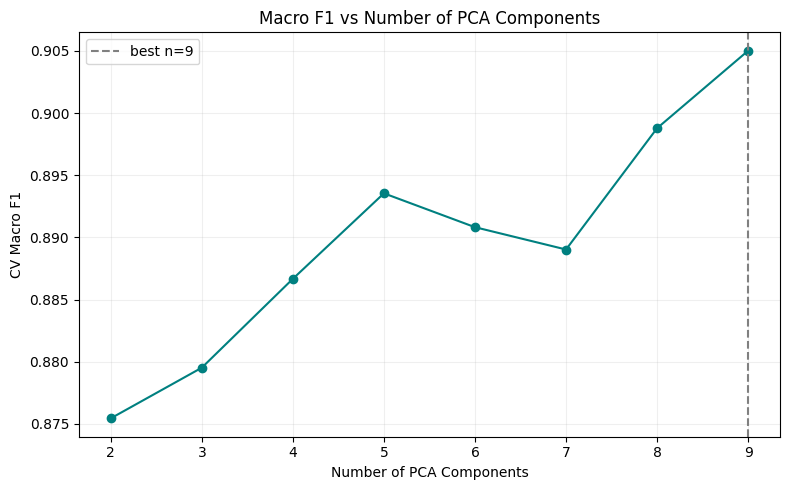

,n_components,cv_macro_f1
0,2,0.8754
1,3,0.8795
2,4,0.8867
3,5,0.8935
4,6,0.8908
5,7,0.8890
6,8,0.8988
7,9,0.9050


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

component_grid = list(range(2, X.shape[1] + 1))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
for n_comp in component_grid:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ])
    f1_macro = cross_val_score(
        model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1
    ).mean()
    scores.append(f1_macro)

best_idx = int(np.argmax(scores))
best_n = component_grid[best_idx]
best_score = scores[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(component_grid, scores, marker="o", color="teal")
plt.axvline(best_n, linestyle="--", color="gray", label=f"best n={best_n}")
plt.title("Macro F1 vs Number of PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("CV Macro F1")
plt.xticks(component_grid)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "n_components": component_grid,
    "cv_macro_f1": scores
}).round(4)

Best result is achieved with9 components (0.905 F1 score), but a local max appears at 5 components too.


The curve is mostly increasing, with a dip around 6–7 components, then improves at 8–9.


For this model (RandomForestClassifier), PCA compression does not help much. Keeping all components gives us the best performance. Given these results, we can expect a drastic F1 and overall accuracy reduction when manually adding noise and simulating sensor errors.

## Feature Importance

We will use SHAP to see how every columns affect the target.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

X = data.drop(columns=[target_col])
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean}) \
    .sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
6,CO,0.35790
7,Proximity_to_Industrial_Areas,0.29210
4,NO2,0.05275
5,SO2,0.03230
1,Humidity,0.02450
0,Temperature,0.01985
8,Population_Density,0.01765
3,PM10,0.00410
2,PM2.5,-0.00195


Given the results, we can see that CO2 and Proximity to industrial Areas have respectively 0.35 and 0.29 percent of weight in the definition of the target column.

Therefore, in order to test sensor failure, we will randomly drop CO2 metrics and check how we get affected.

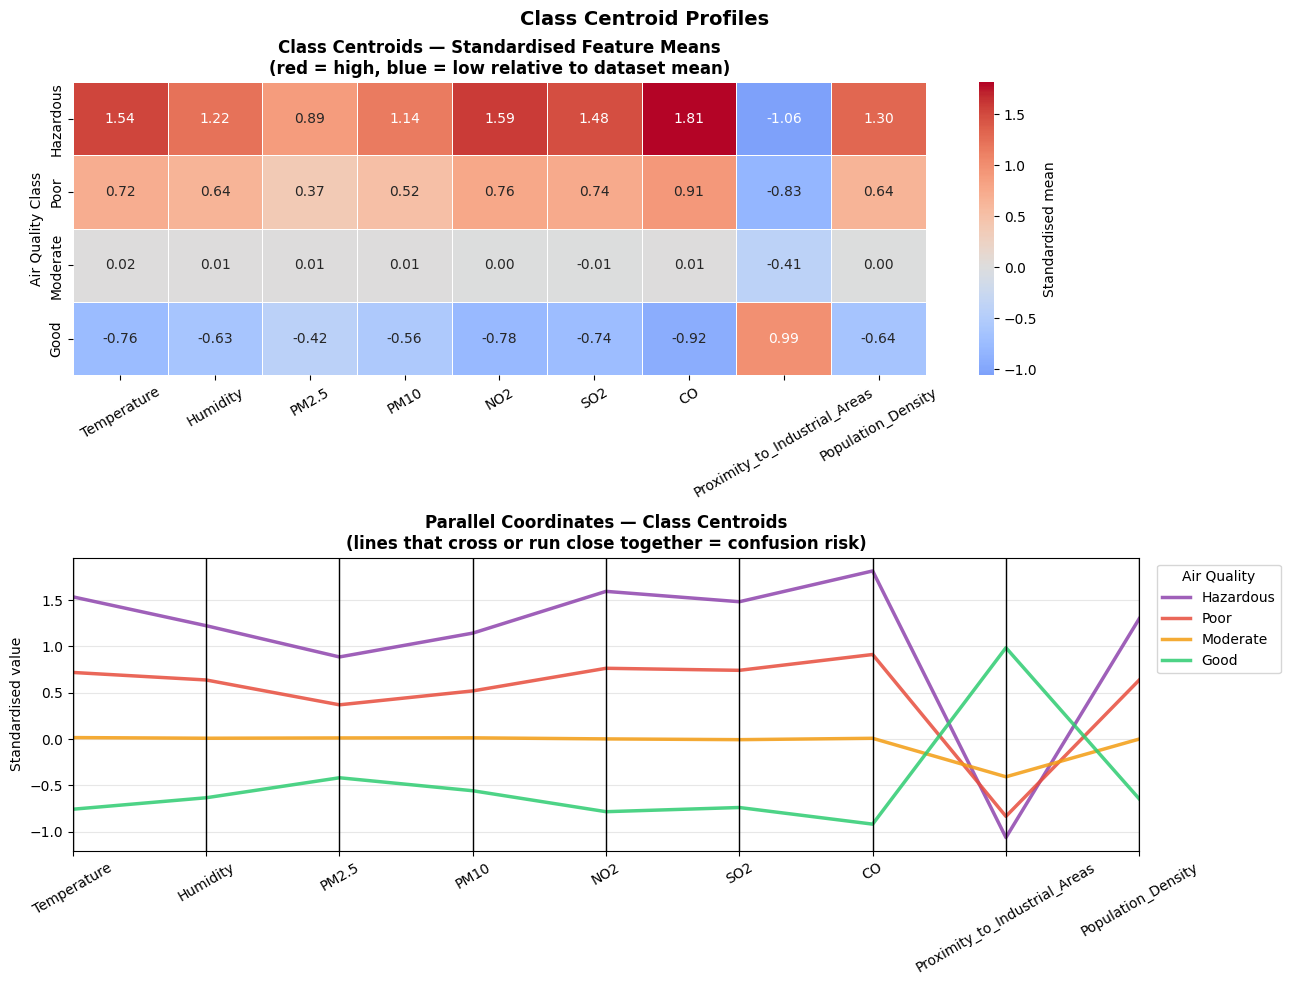

In [ ]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
LABEL_MAP   = {3: "Good", 2: "Moderate", 1: "Poor", 0: "Hazardous"}
PALETTE     = {3: "#2ecc71", 2: "#f39c12", 1: "#e74c3c", 0: "#8e44ad"}
data[target_col] = data[target_col].map(quality_map).astype("int8")

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols]
y = data[target_col]

X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=feature_cols)

classes   = sorted(y.unique())
labels    = [LABEL_MAP[c] for c in classes]
centroids = pd.DataFrame(
    [X_scaled[y == c].mean().values for c in classes],
    index=labels, columns=feature_cols
)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

sns.heatmap(
    centroids, ax=axes[0],
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, cbar_kws={"label": "Standardised mean"},
)
axes[0].set_title("Class Centroids — Standardised Feature Means\n"
                "(red = high, blue = low relative to dataset mean)",
                fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Air Quality Class")
axes[0].tick_params(axis="x", rotation=30)

from pandas.plotting import parallel_coordinates

pc_df = centroids.copy().reset_index().rename(columns={"index": "Air Quality"})

parallel_coordinates(
    pc_df, class_column="Air Quality",
    color=[PALETTE[c] for c in classes],
    linewidth=2.5, alpha=0.85, ax=axes[1]
)
axes[1].set_title("Parallel Coordinates — Class Centroids\n"
                "(lines that cross or run close together = confusion risk)",
                fontweight="bold")
axes[1].set_ylabel("Standardised value")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="Air Quality", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Class Centroid Profiles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The heatmap and parallel coordinates plot show the average feature profile of each class using standardised values. A clear monotonic gradient is visible across all pollution features, `Hazardous` sits clearly above the dataset mean while `Good` sits in the bottom of the plot. With `Poor` and `Moderate` following the same pattern in between those extreme values. The only exception is `Proximity_to_Industrial_Areas`, which completely changes this pattern, as more distance from industry usually corresponds to cleaner air. The parallel coordinates plot reflects this clearly, showing four well-separated lines for every feature, with the exception of the `Proximity_to_Industrial_Areas` marking the highest confusion risk zone. Additionally, `Moderate` is almost flat near zero across every feature, meaning its centroid sits close to the dataset average with little changes, meaning that it is the hardest class to separate from its neighbours.